# Analisis CB-SEM: Kepuasan Pelanggan E-Commerce

Notebook ini mendemonstrasikan **Covariance-Based SEM (CB-SEM)** menggunakan package `lavaan` di R, dengan pendekatan *two-step approach* (Anderson & Gerbing, 1988).

### Model Penelitian

**Variabel Eksogen:**
- **SQ** — Kualitas Layanan (SQ1–SQ4)
- **PV** — Persepsi Nilai (PV1–PV3)
- **TR** — Kepercayaan (TR1–TR4)

**Variabel Endogen:**
- **CS** — Kepuasan Pelanggan (CS1–CS4)
- **CL** — Loyalitas Pelanggan (CL1–CL3)
- **RI** — Niat Beli Ulang (RI1–RI3)

### Hipotesis

| # | Hipotesis | Path |
|---|---|---|
| H1 | Kualitas Layanan berpengaruh positif terhadap Kepuasan | SQ → CS |
| H2 | Persepsi Nilai berpengaruh positif terhadap Kepuasan | PV → CS |
| H3 | Kepercayaan berpengaruh positif terhadap Kepuasan | TR → CS |
| H4 | Kepuasan berpengaruh positif terhadap Loyalitas | CS → CL |
| H5 | Kepercayaan berpengaruh positif terhadap Loyalitas | TR → CL |
| H6 | Kepuasan berpengaruh positif terhadap Niat Beli Ulang | CS → RI |
| H7 | Loyalitas berpengaruh positif terhadap Niat Beli Ulang | CL → RI |

In [1]:
library(lavaan)
library(semPlot)
library(dplyr)

This is lavaan 0.6-19
lavaan is FREE software! Please report any bugs.

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



## 1. Import & Eksplorasi Data

In [2]:
dat <- read.csv("data/sem_ecommerce.csv")
glimpse(dat)

Rows: 300
Columns: 26
$ id        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…
$ gender    <chr> "Perempuan", "Laki-laki", "Perempuan", "Perempuan", "Laki-la…
$ age       <int> 50, 25, 48, 21, 43, 25, 39, 30, 54, 55, 46, 22, 46, 20, 32, …
$ education <chr> "S2", "S1", "S2", "SMA", "D3", "S1", "S2", "SMA", "S2", "S1"…
$ income    <chr> "6-10 juta", "> 10 juta", "< 3 juta", "3-6 juta", "6-10 juta…
$ SQ1       <int> 5, 2, 4, 4, 3, 1, 3, 3, 4, 4, 3, 3, 4, 4, 1, 5, 5, 4, 3, 4, …
$ SQ2       <int> 4, 3, 4, 5, 3, 2, 3, 3, 4, 4, 4, 4, 5, 4, 2, 4, 5, 4, 4, 6, …
$ SQ3       <int> 5, 4, 4, 3, 4, 2, 3, 4, 3, 3, 4, 4, 5, 4, 2, 3, 5, 4, 3, 5, …
$ SQ4       <int> 5, 3, 5, 5, 4, 2, 3, 3, 4, 4, 5, 3, 5, 4, 3, 5, 3, 3, 3, 4, …
$ PV1       <int> 4, 3, 4, 3, 4, 4, 4, 3, 5, 4, 6, 4, 4, 3, 3, 6, 6, 5, 4, 5, …
$ PV2       <int> 5, 5, 5, 3, 4, 3, 6, 3, 4, 3, 5, 4, 3, 2, 4, 6, 5, 4, 3, 3, …
$ PV3       <int> 5, 3, 4, 4, 5, 2, 4, 2, 3, 3, 5, 3, 3, 2, 3, 7, 5, 5, 4, 5, …
$ TR1       <int> 

In [3]:
# Statistik deskriptif indikator
dat |>
  select(SQ1:RI3) |>
  tidyr::pivot_longer(everything(), names_to = "item", values_to = "skor") |>
  summarize(M = mean(skor), SD = sd(skor), .by = item) |>
  arrange(item)

# A tibble: 21 × 3
   item      M    SD
   <chr> <dbl> <dbl>
 1 CL1    3.99 0.894
 2 CL2    3.96 0.949
 3 CL3    4.02 1.02 
 4 CS1    3.99 0.934
 5 CS2    3.98 0.934
 6 CS3    4.05 1.01 
 7 CS4    3.99 0.934
 8 PV1    4.02 0.964
 9 PV2    4.01 1.02 
10 PV3    4.01 1.04 
# ℹ 11 more rows
# ℹ Use `print(n = ...)` to see more rows

## 2. Model Pengukuran (CFA)

Langkah pertama: validasi model pengukuran dengan **Confirmatory Factor Analysis**.

| Ukuran | Baik | Acceptable |
|---|---|---|
| CFI | ≥ 0.95 | ≥ 0.90 |
| TLI | ≥ 0.95 | ≥ 0.90 |
| RMSEA | ≤ 0.06 | ≤ 0.08 |
| SRMR | ≤ 0.08 | ≤ 0.10 |
| Std. Loading | ≥ 0.70 | ≥ 0.50 |
| CR | ≥ 0.70 | — |
| AVE | ≥ 0.50 | — |

In [4]:
# Spesifikasi CFA
model_cfa <- '
  SQ =~ SQ1 + SQ2 + SQ3 + SQ4
  PV =~ PV1 + PV2 + PV3
  TR =~ TR1 + TR2 + TR3 + TR4
  CS =~ CS1 + CS2 + CS3 + CS4
  CL =~ CL1 + CL2 + CL3
  RI =~ RI1 + RI2 + RI3
'

fit_cfa <- cfa(model_cfa, data = dat)
fitMeasures(fit_cfa, c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr"))

  chisq      df  pvalue     cfi     tli   rmsea    srmr 
149.543 174.000   0.910   1.000   1.014   0.000   0.035 

In [5]:
# Standardized loadings
standardizedSolution(fit_cfa) |>
  filter(op == "=~") |>
  select(konstruk = lhs, indikator = rhs, loading = est.std, p = pvalue)

   konstruk indikator loading p
1        SQ       SQ1   0.834 0
2        SQ       SQ2   0.779 0
3        SQ       SQ3   0.709 0
4        SQ       SQ4   0.635 0
5        PV       PV1   0.740 0
6        PV       PV2   0.727 0
7        PV       PV3   0.744 0
8        TR       TR1   0.738 0
9        TR       TR2   0.799 0
10       TR       TR3   0.760 0
11       TR       TR4   0.652 0
12       CS       CS1   0.774 0
13       CS       CS2   0.679 0
14       CS       CS3   0.631 0
15       CS       CS4   0.604 0
16       CL       CL1   0.726 0
17       CL       CL2   0.565 0
18       CL       CL3   0.708 0
19       RI       RI1   0.688 0
20       RI       RI2   0.682 0
21       RI       RI3   0.691 0

In [6]:
# Composite Reliability (CR) & Average Variance Extracted (AVE)
std_load <- standardizedSolution(fit_cfa) |>
  filter(op == "=~") |>
  select(konstruk = lhs, loading = est.std)

std_load |>
  summarize(
    CR  = sum(loading)^2 / (sum(loading)^2 + sum(1 - loading^2)),
    AVE = mean(loading^2),
    .by = konstruk
  )

  konstruk        CR       AVE
1       SQ 0.8301907 0.5525085
2       PV 0.7808402 0.5429089
3       TR 0.8274624 0.5465686
4       CS 0.7684247 0.4557069
5       CL 0.7072876 0.4489746
6       RI 0.7284573 0.4720857

## 3. Model Struktural (Full SEM)

Setelah model pengukuran valid, estimasi model struktural untuk menguji hipotesis.

In [7]:
# Spesifikasi Full SEM
model_sem <- '
  # Model Pengukuran
  SQ =~ SQ1 + SQ2 + SQ3 + SQ4
  PV =~ PV1 + PV2 + PV3
  TR =~ TR1 + TR2 + TR3 + TR4
  CS =~ CS1 + CS2 + CS3 + CS4
  CL =~ CL1 + CL2 + CL3
  RI =~ RI1 + RI2 + RI3

  # Model Struktural
  CS ~ SQ + PV + TR
  CL ~ CS + TR
  RI ~ CS + CL
'

fit_sem <- sem(model_sem, data = dat)
summary(fit_sem, fit.measures = TRUE, standardized = TRUE)

lavaan 0.6-19 ended normally after 34 iterations

  Estimator                                         ML
  Optimization method                           NLMINB
  Number of model parameters                        52

  Number of observations                           300

Model Test User Model:
                                                      
  Test statistic                               152.229
  Degrees of freedom                               179
  P-value (Chi-square)                           0.927

Model Test Baseline Model:

  Test statistic                              2274.102
  Degrees of freedom                               210
  P-value                                        0.000

User Model versus Baseline Model:

  Comparative Fit Index (CFI)                    1.000
  Tucker-Lewis Index (TLI)                       1.015

Loglikelihood and Information Criteria:

  Loglikelihood user model (H0)              -7766.379
  Loglikelihood unrestricted model (H1)      -76

In [8]:
# Koefisien path (standardized)
parameterEstimates(fit_sem, standardized = TRUE) |>
  filter(op == "~") |>
  select(DV = lhs, IV = rhs, B = est, SE = se, Z = z, p = pvalue, Beta = std.all) |>
  mutate(Sig = case_when(
    p < 0.001 ~ "***",
    p < 0.01  ~ "**",
    p < 0.05  ~ "*",
    TRUE      ~ "ns"
  ))

  DV IV     B    SE     Z     p  Beta Sig
1 CS SQ 0.257 0.057 4.505 0.000 0.320 ***
2 CS PV 0.238 0.066 3.595 0.000 0.234 ***
3 CS TR 0.337 0.068 4.920 0.000 0.359 ***
4 CL CS 0.466 0.084 5.579 0.000 0.522 ***
5 CL TR 0.170 0.071 2.411 0.016 0.203   *
6 RI CS 0.319 0.081 3.929 0.000 0.403 ***
7 RI CL 0.309 0.094 3.284 0.001 0.349  **

In [9]:
# R-squared variabel endogen
lavInspect(fit_sem, "r2")

  SQ1   SQ2   SQ3   SQ4   PV1   PV2   PV3   TR1   TR2   TR3   TR4   CS1   CS2 
0.696 0.607 0.503 0.404 0.548 0.533 0.547 0.545 0.637 0.579 0.425 0.602 0.463 
  CS3   CS4   CL1   CL2   CL3   RI1   RI2   RI3    CS    CL    RI 
0.398 0.368 0.525 0.322 0.503 0.474 0.466 0.477 0.452 0.430 0.463 

## 4. Path Diagram

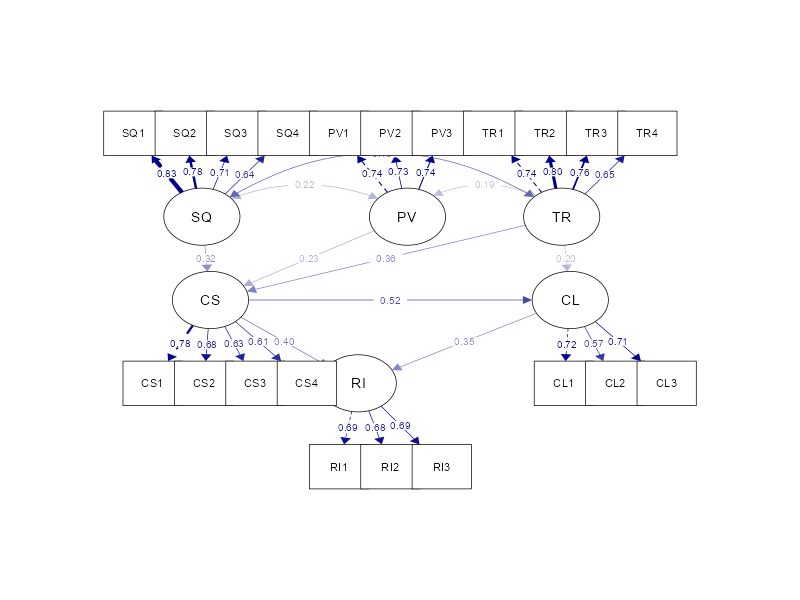

In [10]:
semPaths(fit_sem,
  what = "std", layout = "tree2",
  edge.label.cex = 0.9,
  sizeMan = 7, sizeLat = 9,
  style = "lisrel",
  residuals = FALSE,
  nCharNodes = 3,
  curve = 1.5,
  edge.color = "darkblue")

## 5. Interpretasi

### A. Model Fit

| Ukuran | Nilai | Kriteria | Evaluasi |
|---|---|---|---|
| χ² (df=174) | 149.54 | p > 0.05 | ✅ Baik (p = 0.91) |
| CFI | 1.000 | ≥ 0.95 | ✅ Sangat Baik |
| TLI | 1.014 | ≥ 0.95 | ✅ Sangat Baik |
| RMSEA | 0.000 | ≤ 0.06 | ✅ Sangat Baik |
| SRMR | 0.035 | ≤ 0.08 | ✅ Sangat Baik |

Model fit sangat baik di semua indeks — model teoretis cocok dengan data.

### B. Validitas Konstruk

- **Convergent Validity**: Semua loading ≥ 0.56. CR ≥ 0.70 untuk semua konstruk. AVE untuk SQ, PV, TR ≥ 0.50 (baik). CS, CL, RI sedikit di bawah 0.50 tapi CR masih baik — masih acceptable.
- **Catatan**: Beberapa loading (CS4=0.60, CL2=0.57) marginal. Dalam riset nyata, pertimbangkan untuk memeriksa cross-loading.

### C. Pengujian Hipotesis

| # | Path | β | p-value | Keputusan |
|---|---|---|---|---|
| H1 | SQ → CS | 0.320 | < 0.001 | ✅ **Didukung** |
| H2 | PV → CS | 0.234 | < 0.001 | ✅ **Didukung** |
| H3 | TR → CS | 0.359 | < 0.001 | ✅ **Didukung** |
| H4 | CS → CL | 0.522 | < 0.001 | ✅ **Didukung** |
| H5 | TR → CL | 0.203 | 0.016 | ✅ **Didukung** |
| H6 | CS → RI | 0.403 | < 0.001 | ✅ **Didukung** |
| H7 | CL → RI | 0.349 | 0.001 | ✅ **Didukung** |

**Semua 7 hipotesis didukung** (p < 0.05 dengan arah positif sesuai teori).

### D. R² Variabel Endogen

| Variabel | R² | Interpretasi |
|---|---|---|
| CS (Kepuasan) | 0.452 | Moderat — 45% variasi dijelaskan oleh SQ, PV, TR |
| CL (Loyalitas) | 0.430 | Moderat — 43% dijelaskan oleh CS dan TR |
| RI (Niat Beli Ulang) | 0.463 | Moderat — 46% dijelaskan oleh CS dan CL |

### E. Temuan Kunci

1. **Kepercayaan (TR → CS, β=0.36)** adalah prediktor terkuat kepuasan — lebih kuat dari kualitas layanan dan persepsi nilai. Ini konsisten dengan literatur e-commerce di mana trust sangat krusial.
2. **Kepuasan → Loyalitas (β=0.52)** adalah path terkuat dalam model — sejalan dengan teori ACSI.
3. TR juga berpengaruh langsung ke CL (β=0.20), menunjukkan bahwa kepercayaan memiliki **efek langsung dan tidak langsung** terhadap loyalitas.
4. Baik kepuasan maupun loyalitas berkontribusi signifikan terhadap niat beli ulang, dengan CS (β=0.40) sedikit lebih kuat dari CL (β=0.35).

## 6. Latihan

### Latihan 1: Modifikasi Model

Hapus path `TR → CL` dan bandingkan fit model (chi-square difference test).

```r
model_sem2 <- '
  SQ =~ SQ1 + SQ2 + SQ3 + SQ4
  PV =~ PV1 + PV2 + PV3
  TR =~ TR1 + TR2 + TR3 + TR4
  CS =~ CS1 + CS2 + CS3 + CS4
  CL =~ CL1 + CL2 + CL3
  RI =~ RI1 + RI2 + RI3

  CS ~ SQ + PV + TR
  CL ~ CS            # TR dihapus
  RI ~ CS + CL
'
# fit_sem2 <- sem(model_sem2, data = dat)
# anova(fit_sem, fit_sem2)
```

### Latihan 2: Analisis Mediasi

Hitung efek tidak langsung SQ → RI melalui CS dan CL.

```r
model_med <- '
  SQ =~ SQ1 + SQ2 + SQ3 + SQ4
  PV =~ PV1 + PV2 + PV3
  TR =~ TR1 + TR2 + TR3 + TR4
  CS =~ CS1 + CS2 + CS3 + CS4
  CL =~ CL1 + CL2 + CL3
  RI =~ RI1 + RI2 + RI3

  CS ~ a*SQ + PV + TR
  CL ~ b*CS + TR
  RI ~ c*CS + d*CL

  indirect1 := a * c          # SQ -> CS -> RI
  indirect2 := a * b * d      # SQ -> CS -> CL -> RI
  total_indirect := indirect1 + indirect2
'
# fit_med <- sem(model_med, data = dat)
# parameterEstimates(fit_med) |> filter(op == ":=")
```

### Latihan 3: Multi-Group Analysis

Bandingkan model antara laki-laki dan perempuan.

```r
# fit_mg <- sem(model_sem, data = dat, group = "gender")
# summary(fit_mg)
```